# ANOVA - Complete Practice Notebook

**What is ANOVA?**
ANOVA (Analysis of Variance) is used to compare the means
of THREE or more groups at the same time, to check if
at least one group is significantly different from the rest.

**When to use ANOVA?**
- Comparing means across 3 or more groups
- Data is numerical
- Groups are independent of each other

**Why not just use multiple T-Tests?**
Running T-Tests again and again between every pair of groups
increases the chance of error. ANOVA checks all groups
together in a single test.

**Types of ANOVA:**
- One-Way ANOVA → One categorical variable with 3+ groups
- Two-Way ANOVA → Two categorical variables together

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 1. Theory

**Hypothesis:**
- H0 (Null Hypothesis)      → All group means are EQUAL
- H1 (Alternate Hypothesis) → At least ONE group mean is DIFFERENT

**F-Statistic Formula:**
F = Variance Between Groups / Variance Within Groups

**Decision Rule:**
- If p-value < 0.05 → Reject H0 → At least one group is significantly different
- If p-value > 0.05 → Accept H0 → All groups are similar

**Important Note:**
ANOVA tells you that a difference EXISTS,
but not WHICH groups differ. For that, we use a
Post-Hoc test (like Tukey's HSD) afterward.

## Dataset

A simple study on **3 different study methods** and the
exam scores of students who used each method.

- Group A → Self Study
- Group B → Online Classes
- Group C → Offline Coaching

5 students in each group, easy to verify by hand.

In [2]:
data = {
    "Student" : [f"S{i+1}" for i in range(15)],
    "Method"  : ["Self Study"] * 5 + ["Online Classes"] * 5 + ["Offline Coaching"] * 5,
    "Score"   : [60, 65, 58, 62, 64,
                 70, 75, 72, 68, 74,
                 80, 85, 78, 82, 84]
}

df = pd.DataFrame(data)
print(df)

   Student            Method  Score
0       S1        Self Study     60
1       S2        Self Study     65
2       S3        Self Study     58
3       S4        Self Study     62
4       S5        Self Study     64
5       S6    Online Classes     70
6       S7    Online Classes     75
7       S8    Online Classes     72
8       S9    Online Classes     68
9      S10    Online Classes     74
10     S11  Offline Coaching     80
11     S12  Offline Coaching     85
12     S13  Offline Coaching     78
13     S14  Offline Coaching     82
14     S15  Offline Coaching     84


In [4]:
# Group wise Summary

summary = df.groupby("Method")["Score"].agg(
    Mean  = "mean",
    Std   = "std",
    Count = "count"
)

print(summary)

                  Mean       Std  Count
Method                                 
Offline Coaching  81.8  2.863564      5
Online Classes    71.8  2.863564      5
Self Study        61.8  2.863564      5


## 2. One-Way ANOVA

**Question:**
Does the study method affect exam scores?

**H0:** Mean score of Self Study = Online Classes = Offline Coaching
**H1:** At least one method has a significantly different mean score

In [5]:
self_study = df[df["Method"] == "Self Study"]["Score"]
online = df[df["Method"] == "Online Classes"]["Score"]
offline = df[df["Method"] == "Offline Coaching"]["Score"]

f_stat, p_val = stats.f_oneway(self_study, online, offline)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_val:.4f}")

F-Statistic : 60.9756
P-Value     : 0.0000


## Manual Calculation (For Understanding)

Let's break the F-statistic down manually using the basic idea:
- Variance Between Groups (how far group means are from overall mean)
- Variance Within Groups (how spread out scores are inside each group)

In [7]:
overall_mean = df["Score"].mean()
print(f"Overall Mean: {overall_mean:.2f}\n")

groups = [self_study, online, offline]
group_names = ["Self Study", "Online Classes", "Offline Coaching"]

# Between Group Sum of Squares
ss_between = sum(len(g) * (g.mean() - overall_mean) ** 2 for g in groups)

# Within Group Sum of Squares
ss_within = sum(((g - g.mean()) ** 2).sum() for g in groups)

k = len(groups)            # number of groups
n = len(df)                 # total observations

df_between = k - 1
df_within  = n - k

ms_between = ss_between / df_between
ms_within  = ss_within / df_within

manual_f = ms_between / ms_within

print(f"SS Between : {ss_between:.2f}")
print(f"SS Within : {ss_within:.2f}")
print(f"df Between : {df_between}")
print(f"df Within : {df_within}")
print(f"MS Between : {ms_between:.2f}")
print(f"MS Within : {ms_within:.2f}")
print(f"\nManual F-Statistic : {manual_f:.4f}")
print(f"Scipy F-Statistic : {f_stat:.4f}")


if p_val < 0.05:
    print("\nReject H0")
else:
    print("\nAccept H0")

Overall Mean: 71.80

SS Between : 1000.00
SS Within : 98.40
df Between : 2
df Within : 12
MS Between : 500.00
MS Within : 8.20

Manual F-Statistic : 60.9756
Scipy F-Statistic : 60.9756

Reject H0


/tmp/ipykernel_7030/287146883.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Method", y="Score", palette="Set2", ax=axes[0])
/tmp/ipykernel_7030/287146883.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Method", y="Score", palette="Set1", ax=axes[1])


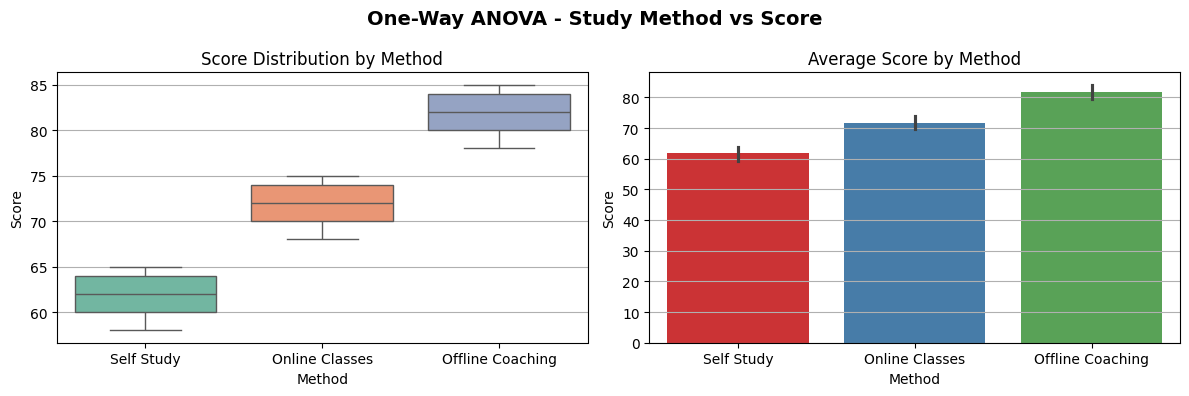

In [10]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box Plot
sns.boxplot(data=df, x="Method", y="Score", palette="Set2", ax=axes[0])
axes[0].set_title("Score Distribution by Method")
axes[0].grid(axis="y")

# Bar Plot with Mean
sns.barplot(data=df, x="Method", y="Score", palette="Set1", ax=axes[1])
axes[1].set_title("Average Score by Method")
axes[1].grid(axis="y")

plt.suptitle("One-Way ANOVA - Study Method vs Score", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Post-Hoc Test — Tukey's HSD

ANOVA only tells us THAT a difference exists,
not WHICH groups are different from each other.

Tukey's HSD (Honestly Significant Difference) test
compares every pair of groups to find exactly
where the difference lies.

In [11]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(endog=df["Score"], groups=df["Method"], alpha=0.05)
print(tukey_result)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1          group2     meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------
Offline Coaching Online Classes    -10.0 0.0004 -14.8317  -5.1683   True
Offline Coaching     Self Study    -20.0    0.0 -24.8317 -15.1683   True
  Online Classes     Self Study    -10.0 0.0004 -14.8317  -5.1683   True
------------------------------------------------------------------------


<Figure size 800x400 with 0 Axes>

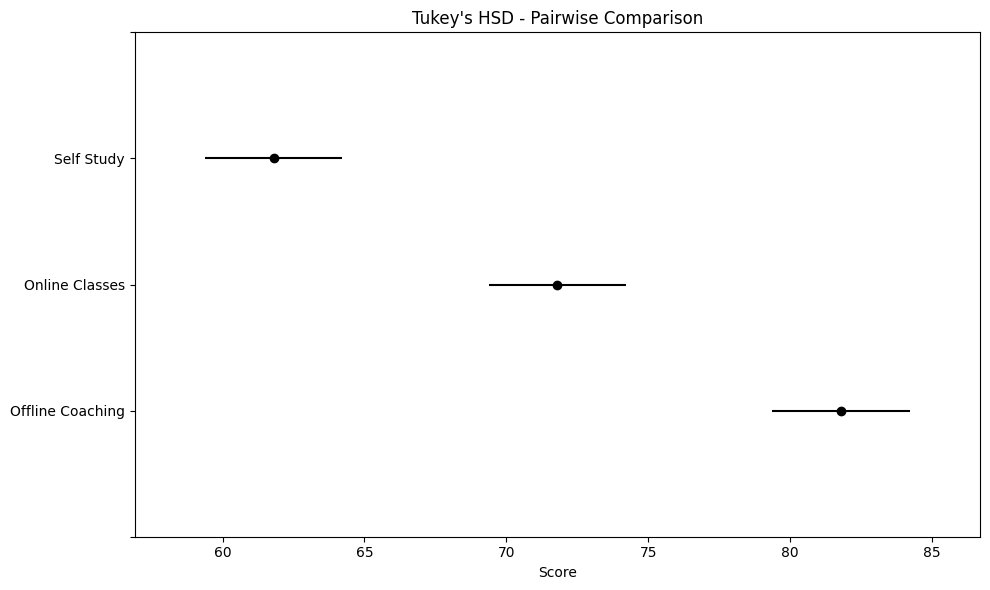

In [12]:
plt.figure(figsize=(8, 4))
tukey_result.plot_simultaneous()
plt.title("Tukey's HSD - Pairwise Comparison")
plt.xlabel("Score")
plt.tight_layout()
plt.show()